# Quantum Neural Networks and Quantum Support Vector Machines

In the previous class, we introduced:

- quantum feature maps,
- `AngleEmbedding` and `AmplitudeEmbedding`,
- quantum kernels,
- variational quantum circuits,
- parameterized ansätze,
- gradients and parameter-shift,
- an end-to-end VQC binary classifier.

This notebook builds directly on those ideas. The two central models here are:

- **QNNs:** trainable quantum circuits used as learning models.
- **QSVMs:** classical SVMs whose kernel entries are computed by quantum circuits.

In [1]:
# Setup

import importlib.util
import subprocess
import sys
import warnings

packages = [
    ("pennylane", "pennylane"),
    ("scikit-learn", "sklearn"),
]

for pip_name, import_name in packages:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import pennylane as qml
from pennylane import numpy as np

import numpy as onp
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

warnings.filterwarnings("ignore")

rng = onp.random.default_rng(42)

---
# Short recap: two ways to use a quantum circuit in supervised learning

A supervised learning dataset has inputs and labels:

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N.
$$

In the **classical-data / quantum-model** setting, the input $\mathbf{x}$ is encoded into a quantum state:

$$
\mathbf{x} \longmapsto |\phi(\mathbf{x})\rangle.
$$

After that, there are two common learning strategies.

---

## Strategy A: Train a quantum circuit directly

A trainable circuit has parameters $\boldsymbol{\theta}$:

$$
f(\mathbf{x}; \boldsymbol{\theta})
=
\langle 0 |
U^\dagger(\mathbf{x}, \boldsymbol{\theta})
\hat{O}
U(\mathbf{x}, \boldsymbol{\theta})
|0\rangle.
$$

You start at 0, apply the circuit $U$ to encode data and rotate qubits, measure an observable $\hat{O}$, and the resulting number is your model's prediction. The circuit output is used like a neural-network prediction. We train $\boldsymbol{\theta}$ by minimizing a classical loss function. This is the QNN / variational classifier style.

---

## Strategy B: Use the quantum circuit only to compute similarities

A quantum kernel is

$$
k(\mathbf{x}, \mathbf{x}')
=
|\langle \phi(\mathbf{x}) | \phi(\mathbf{x}') \rangle|^2.
$$

The quantum computer estimates pairwise similarities. Then a classical kernel method, such as an SVM, performs the final optimization. This is the QSVM / quantum-kernel style used in this notebook.

---
# 1. Quantum Neural Networks (QNNs)

## 1.1 What is a QNN?

The term **Quantum Neural Network** is used in several ways in the literature. In near-term quantum machine learning, the most common meaning is:

> A QNN is a parameterized quantum circuit used as a trainable model inside a hybrid quantum-classical optimization loop.

The model has the same high-level ingredients as a classical neural network:

| Classical neural network | Quantum neural network |
|---|---|
| input features | encoded into quantum states |
| trainable weights | rotation angles / circuit parameters |
| layers | repeated blocks of gates |
| nonlinear activation | measurement plus classical loss can induce nonlinear decision rules |
| optimizer | classical optimizer, such as gradient descent or Adam |

A typical QNN has four blocks:

$$
\boxed{
\text{data encoding}
\rightarrow
\text{trainable ansatz}
\rightarrow
\text{measurement}
\rightarrow
\text{classical loss}
}
$$

---

## 1.2 A useful mental model

A QNN is not simply a classical neural network placed on a quantum computer. Instead, it is a **trainable quantum feature transformation** followed by measurement.

For binary classification, a common choice is:

$$
\hat{y}(\mathbf{x})
=
\operatorname{sign}
\left(
\langle Z_0 \rangle
\right),
$$

where $\langle Z_0\rangle \in [-1,1]$ is the expectation value of the Pauli-$Z$ observable on qubit 0.

For regression, the raw value $\langle Z_0\rangle$ can be interpreted as a continuous prediction in $[-1,1]$.

---

## 1.3 Why QNNs are interesting

QNNs are interesting because quantum circuits can create feature transformations based on:

- **superposition,**
- **interference,**
- **entanglement,**
- high-dimensional Hilbert spaces,
- trainable measurement statistics.

However, they also face practical limitations:

- small number of qubits,
- noisy gates,
- costly data encoding,
- many circuit evaluations during training,
- barren plateaus in deep random circuits,
- no general guarantee of advantage over classical models.

---

Weight tensor shape: (2, 2, 3)
Number of trainable parameters: 12
Circuit output: 0.7436022202271642


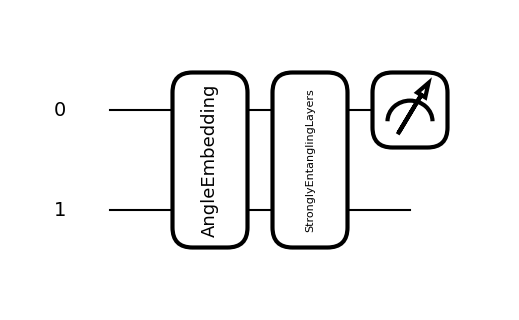

In [2]:
# A minimal QNN circuit: We use two qubits because the circuit is small enough to draw, but still allows entanglement.

n_qubits_demo = 2
n_layers_demo = 2

dev_demo = qml.device("default.qubit", wires=n_qubits_demo)

@qml.qnode(dev_demo)
def qnn_demo(weights, x):
    # 1. Encode the classical input x into rotation angles
    qml.AngleEmbedding(features=x, wires=range(n_qubits_demo), rotation="Y")

    # 2. Apply trainable layers
    qml.StronglyEntanglingLayers(weights=weights, wires=range(n_qubits_demo))

    # 3. Measure one observable: Since the goal is often to produce a single scalar value (e.g., a prediction between -1 and 1), the expectation value of one observable on one qubit provides exactly that.
    return qml.expval(qml.PauliZ(0))

shape_demo = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers_demo,
    n_wires=n_qubits_demo
)

weights_demo = np.array(
    rng.normal(loc=0.0, scale=0.3, size=shape_demo),
    requires_grad=False
)

x_demo = np.array([0.4, 1.2], requires_grad=False)

print("Weight tensor shape:", shape_demo)
print("Number of trainable parameters:", weights_demo.size)
print("Circuit output:", qnn_demo(weights_demo, x_demo))

fig, ax = qml.draw_mpl(qnn_demo, decimals=2)(weights_demo, x_demo)
plt.show()

## 1.5 Interpreting the circuit

The previous circuit contains three conceptual pieces.

### Data encoding

`AngleEmbedding` maps each feature to a rotation gate:

$$
x_j \mapsto R_Y(x_j).
$$

For two features, we use two qubits.

### Trainable ansatz

`StronglyEntanglingLayers` applies trainable single-qubit rotations and entangling gates. The trainable tensor has shape:

$$
(\text{number of layers}, \text{number of wires}, 3).
$$

The final dimension is 3 because each local trainable block uses three Euler-angle rotations.

### Measurement

The circuit returns:

$$
\langle Z_0\rangle.
$$

This value is a real number in $[-1,1]$. It can be used as a regression prediction or converted into a class label by taking its sign.

### Visualizing the '3-parameter' rotation
To see how those 3 parameters are used, we can look at a single `qml.Rot` gate, which is what `StronglyEntanglingLayers` uses internally. Notice it takes exactly three coordinates to define one single gate operation.

In [3]:
def single_gate_demo():
    # This is the 'special gate' inside the layers
    # It takes 3 parameters for 1 gate on 1 qubit
    qml.Rot(0.1, 0.2, 0.3, wires=0)
    return qml.expval(qml.PauliZ(0))

dev = qml.device("default.qubit", wires=1)
qnode_demo = qml.QNode(single_gate_demo, dev)

print("Circuit with a single 3-parameter gate:")
print(qml.draw(qnode_demo)())

# We manually construct the tape to look at the internal operations
tape = qml.workflow.construct_tape(qnode_demo)()

print("\nDecomposition of that gate into RZ and RY:")
for op in tape.operations:
    # Decompose the Rot gate into simpler gates
    for decomp_op in op.decomposition():
        print(decomp_op)

Circuit with a single 3-parameter gate:
0: ──Rot(0.10,0.20,0.30)─┤  <Z>

Decomposition of that gate into RZ and RY:
RZ(0.1, wires=[0])
RY(0.2, wires=[0])
RZ(0.3, wires=[0])


### Exercise 1.A — Reading and modifying a QNN circuit

Use the previous code cell.

1. Change `n_layers_demo` from 2 to 1, 3, and 4.
2. For each case, print the number of parameters.
3. Draw the circuit for 3 layers.
4. Replace the measurement `qml.PauliZ(0)` with `qml.PauliZ(1)`.
5. Answer in words: does changing the measured qubit change the model? Why?

With PauliZ(0)
Weight tensor shape: (1, 2, 3)
Number of trainable parameters for 1 layers: 6
Circuit output: 0.3783721336479288
Weight tensor shape: (2, 2, 3)
Number of trainable parameters for 2 layers: 12
Circuit output: 0.21541287249244234
Weight tensor shape: (3, 2, 3)
Number of trainable parameters for 3 layers: 18
Circuit output: 0.7153649915345739
Circuit 3 layers


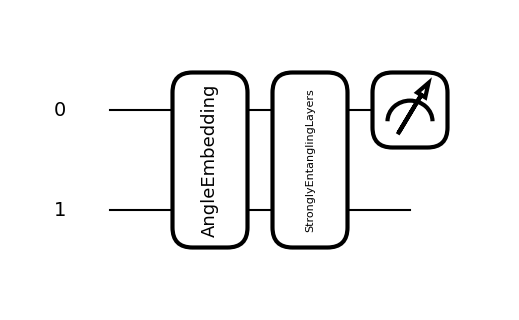

Weight tensor shape: (4, 2, 3)
Number of trainable parameters for 4 layers: 24
Circuit output: 0.54229187736199
##############################
With PauliZ(1)
Weight tensor shape: (1, 2, 3)
Number of trainable parameters for 1 layers: 6
Circuit output: 0.3504182994881687
Weight tensor shape: (2, 2, 3)
Number of trainable parameters for 2 layers: 12
Circuit output: 0.7635457263752404
Weight tensor shape: (3, 2, 3)
Number of trainable parameters for 3 layers: 18
Circuit output: 0.6371047820359341
Circuit 3 layers


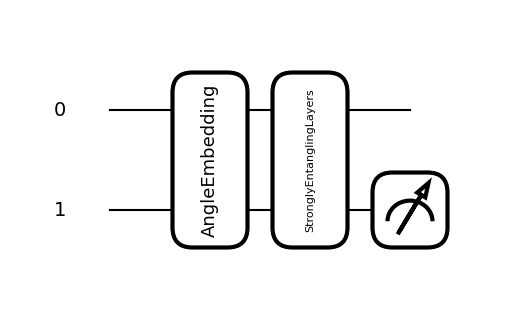

Weight tensor shape: (4, 2, 3)
Number of trainable parameters for 4 layers: 24
Circuit output: -0.263592840451194


In [15]:
# A minimal QNN circuit: We use two qubits because the circuit is small enough to draw, but still allows entanglement.

n_qubits_demo = 2
n_layers_demo = 2

dev_demo_ex = qml.device("default.qubit", wires=n_qubits_demo)

@qml.qnode(dev_demo_ex)
def qnn_demo_ex_pauli0(weights, x):
    # 1. Encode the classical input x into rotation angles
    qml.AngleEmbedding(features=x, wires=range(n_qubits_demo), rotation="Y")

    # 2. Apply trainable layers
    qml.StronglyEntanglingLayers(weights=weights, wires=range(n_qubits_demo))

    # 3. Measure one observable: Since the goal is often to produce a single scalar value (e.g., a prediction between -1 and 1), the expectation value of one observable on one qubit provides exactly that.
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev_demo_ex)
def qnn_demo_ex_pauli1(weights, x):
    # 1. Encode the classical input x into rotation angles
    qml.AngleEmbedding(features=x, wires=range(n_qubits_demo), rotation="Y")

    # 2. Apply trainable layers
    qml.StronglyEntanglingLayers(weights=weights, wires=range(n_qubits_demo))

    # 3. Measure one observable: Since the goal is often to produce a single scalar value (e.g., a prediction between -1 and 1), the expectation value of one observable on one qubit provides exactly that.
    return qml.expval(qml.PauliZ(1))

print("With PauliZ(0)")
for i in range(1,5,1):
    n_layers_demo=i
    shape_demo = qml.StronglyEntanglingLayers.shape(
        n_layers=n_layers_demo,
        n_wires=n_qubits_demo
    )

    weights_demo = np.array(
        rng.normal(loc=0.0, scale=0.3, size=shape_demo),
        requires_grad=False
    )
    x_demo = np.array([0.4, 1.2], requires_grad=False)

    print("Weight tensor shape:", shape_demo)
    print(f"Number of trainable parameters for {i} layers:", weights_demo.size)
    print("Circuit output:", qnn_demo_ex_pauli0(weights_demo, x_demo))
    if i==3:
        print("Circuit 3 layers")
        fig, ax = qml.draw_mpl(qnn_demo_ex_pauli0, decimals=2)(weights_demo, x_demo)
        plt.show()
        
        
print(30*"#")
    
print("With PauliZ(1)")
for i in range(1,5,1):
    n_layers_demo=i
    shape_demo = qml.StronglyEntanglingLayers.shape(
        n_layers=n_layers_demo,
        n_wires=n_qubits_demo
    )

    weights_demo = np.array(
        rng.normal(loc=0.0, scale=0.3, size=shape_demo),
        requires_grad=False
    )
    x_demo = np.array([0.4, 1.2], requires_grad=False)

    print("Weight tensor shape:", shape_demo)
    print(f"Number of trainable parameters for {i} layers:", weights_demo.size)
    print("Circuit output:", qnn_demo_ex_pauli1(weights_demo, x_demo))
    if i==3:
        print("Circuit 3 layers")
        fig, ax = qml.draw_mpl(qnn_demo_ex_pauli1, decimals=2)(weights_demo, x_demo)
        plt.show()

Changing the qubit to which we apply PauliZ did change the results.

---
# 2. QNN example 1: a small quantum regressor

## 2.1 Practical example: sensor calibration

Suppose a small sensor produces one normalized input feature $x$, such as:

- temperature,
- vibration level,
- pressure,
- normalized voltage,
- light intensity.

We want to predict a continuous target $y$, such as a calibrated risk score or corrected measurement.

This is a simple regression problem:

$$
x \longmapsto y.
$$

We will train a one-qubit QNN to approximate a smooth function. This is not meant to outperform classical regression. It is a controlled example showing how a QNN learns by adjusting circuit parameters.

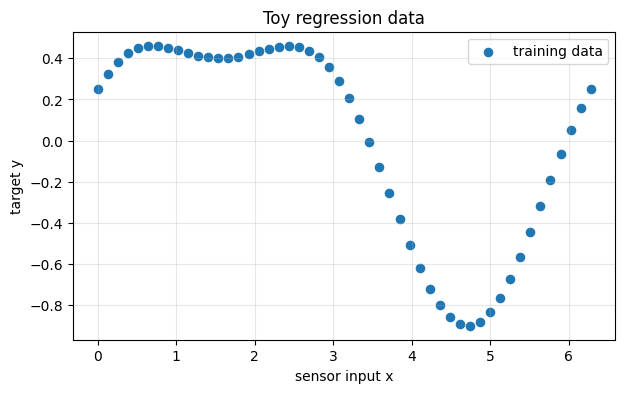

In [16]:
# Generate a small regression dataset

# One feature in the interval [0, 2π]
X_reg = np.array(onp.linspace(0, 2 * onp.pi, 50), requires_grad=False)

# A smooth target in [-1, 1]. Think of this as a toy calibrated sensor response.
y_reg = np.array(
    0.65 * onp.sin(onp.asarray(X_reg)) + 0.25 * onp.cos(2 * onp.asarray(X_reg)),
    requires_grad=False
)

plt.figure(figsize=(7, 4))
plt.scatter(onp.asarray(X_reg), onp.asarray(y_reg), s=35, label="training data")
plt.xlabel("sensor input x")
plt.ylabel("target y")
plt.title("Toy regression data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Number of trainable parameters: 4
Initial prediction at x = 1.0: -0.2359103404747055


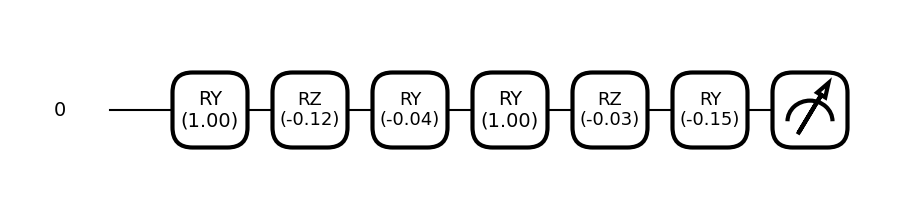

In [28]:

# Define a one-qubit QNN regressor

n_layers_reg = 2
dev_reg = qml.device("default.qubit", wires=1)

@qml.qnode(dev_reg, interface="autograd", diff_method="backprop")
def qnn_regressor(params, x):
    for layer in range(n_layers_reg):
        qml.RY(x, wires=0)
        qml.RZ(params[2 * layer], wires=0)      # trainable phase
        qml.RY(params[2 * layer + 1], wires=0)  # trainable rotation
    return qml.expval(qml.PauliZ(0))

params_reg = np.array(
    0.1 * rng.normal(size=2 * n_layers_reg),
    requires_grad=True
)

print("Number of trainable parameters:", len(params_reg))
print("Initial prediction at x = 1.0:", qnn_regressor(params_reg, 1.0))

fig, ax = qml.draw_mpl(qnn_regressor, decimals=2)(params_reg, 1.0)
plt.show()

step   0 | loss = 0.674222
step  25 | loss = 0.001827
step  50 | loss = 0.002582
step  75 | loss = 0.000215
step 100 | loss = 0.000015
step 125 | loss = 0.000000
step 139 | loss = 0.000000


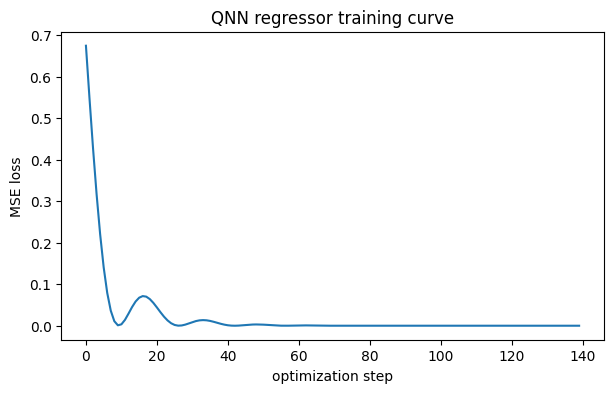

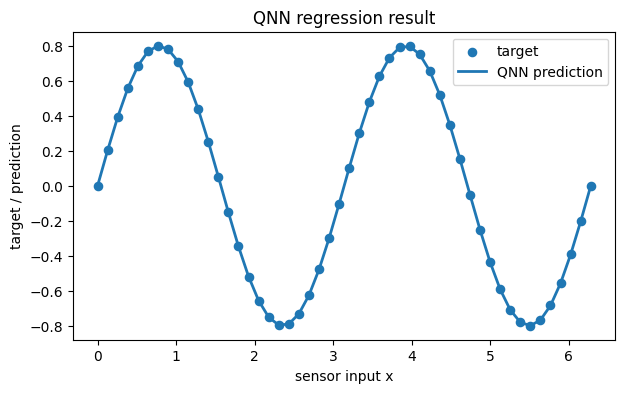

In [29]:
# Train the QNN regressor
y_reg = np.array(
    0.8 * onp.sin(onp.asarray(2*X_reg)),
    requires_grad=False
)


def regression_loss(params):
    preds = np.stack([qnn_regressor(params, x) for x in X_reg])
    return np.mean((preds - y_reg) ** 2)

opt = qml.AdamOptimizer(stepsize=0.08)

loss_history_reg = []
n_steps_reg = 140

for step in range(n_steps_reg):
    params_reg, loss_value = opt.step_and_cost(regression_loss, params_reg)
    loss_history_reg.append(float(loss_value))

    if step % 25 == 0 or step == n_steps_reg - 1:
        print(f"step {step:3d} | loss = {float(loss_value):.6f}")

# Predictions after training
preds_reg = onp.array([float(qnn_regressor(params_reg, x)) for x in X_reg])

plt.figure(figsize=(7, 4))
plt.plot(loss_history_reg)
plt.xlabel("optimization step")
plt.ylabel("MSE loss")
plt.title("QNN regressor training curve")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(onp.asarray(X_reg), onp.asarray(y_reg), s=35, label="target")
plt.plot(onp.asarray(X_reg), preds_reg, linewidth=2, label="QNN prediction")
plt.xlabel("sensor input x")
plt.ylabel("target / prediction")
plt.title("QNN regression result")
plt.legend()
plt.show()

## 2.5 What happened during training?

The QNN output is always an expectation value, so it lies in $[-1,1]$. The optimizer adjusts rotation angles so that:

$$
\langle Z \rangle_{\boldsymbol{\theta}, x}
\approx
y.
$$

This example demonstrates three important ideas:

1. **The circuit is the model.**  
   The architecture determines what functions can be represented.

2. **The loss is classical.**  
   We compute mean squared error exactly as in classical regression.

3. **The optimizer is classical.**  
   The quantum circuit is evaluated many times, while the optimizer updates classical parameters.

For larger circuits, training can become expensive because each gradient step requires many circuit evaluations.

### Exercise 2.A — Changing the QNN regressor

Starting from the previous regressor:

1. Change `n_layers_reg` from 4 to 1 and retrain.
2. Change `n_layers_reg` from 4 to 8 and retrain.
3. Compare the final loss values.
4. Change the target function to:

$$
y = 0.8\sin(2x).
$$

5. Which circuit depth learns this new function better?

**Discussion question:** When does increasing circuit depth help, and when might it hurt?

### With n_layers_reg = 1 the results were the following:

step   0 | loss = 0.721685

step  25 | loss = 0.048296

step  50 | loss = 0.036267

step  75 | loss = 0.031900

step 100 | loss = 0.031857

step 125 | loss = 0.031828

step 139 | loss = 0.031826

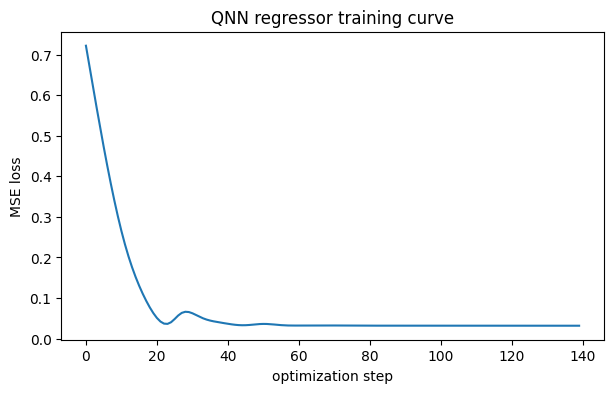

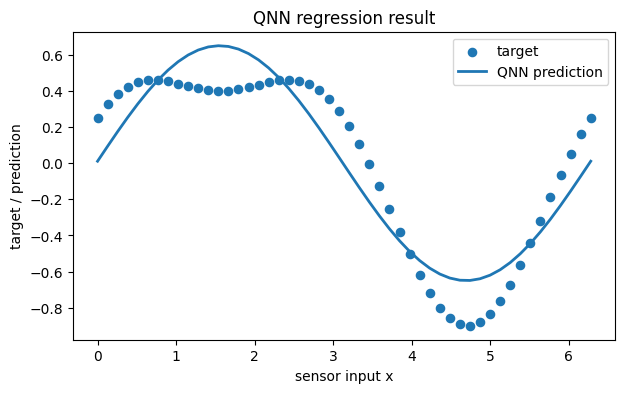

### With n_layers_reg = 8 the results were the following:

step   0 | loss = 0.730933

step  25 | loss = 0.110518

step  50 | loss = 0.006677

step  75 | loss = 0.002786

step 100 | loss = 0.001601

step 125 | loss = 0.000618

step 139 | loss = 0.000468

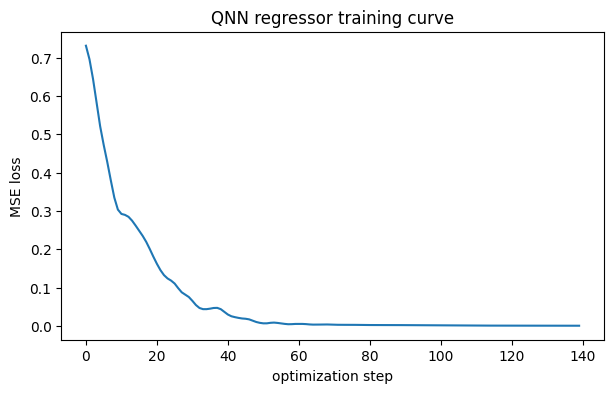

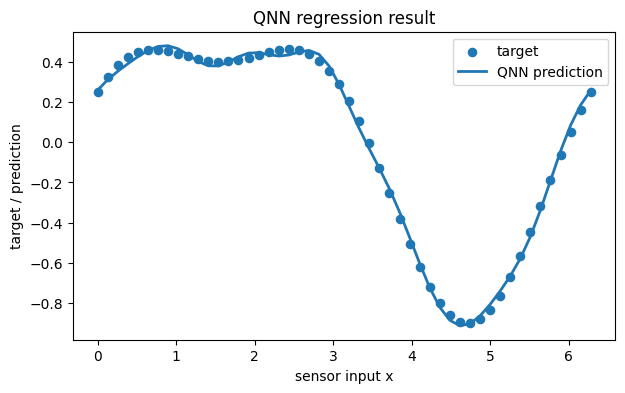


The line fitted was better for 8 layers than for 1, and the loss was significantly smaller with 8 layers than with 1.


#### For the new y function y=0.8*sin(2x)

### With n_layers_reg = 1 the results were the following:


step   0 | loss = 0.822625

step  25 | loss = 0.370069

step  50 | loss = 0.314838

step  75 | loss = 0.313751

step 100 | loss = 0.313609

step 125 | loss = 0.313602

step 139 | loss = 0.313600

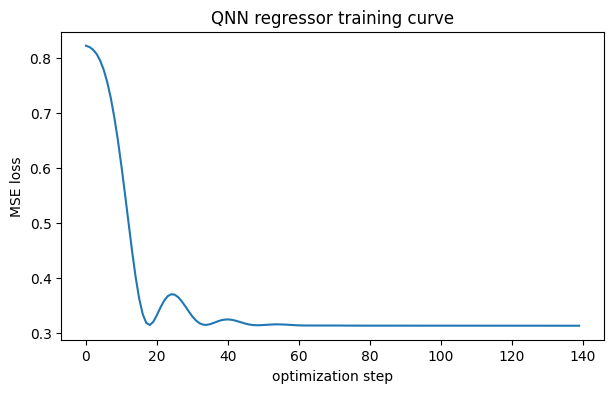

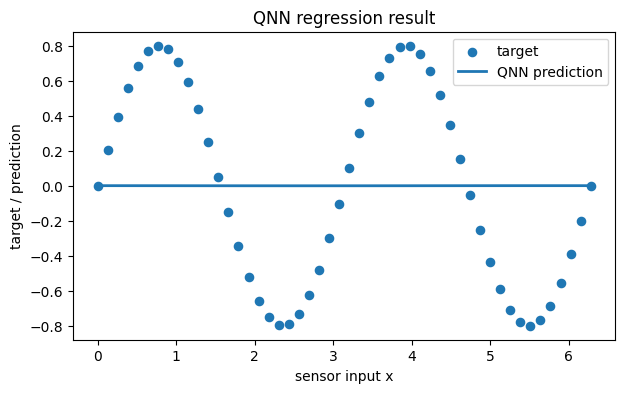

For 8 layers

step   0 | loss = 0.552078

step  25 | loss = 0.013578

step  50 | loss = 0.002973

step  75 | loss = 0.000604

step 100 | loss = 0.000471

step 125 | loss = 0.000402

step 139 | loss = 0.000373

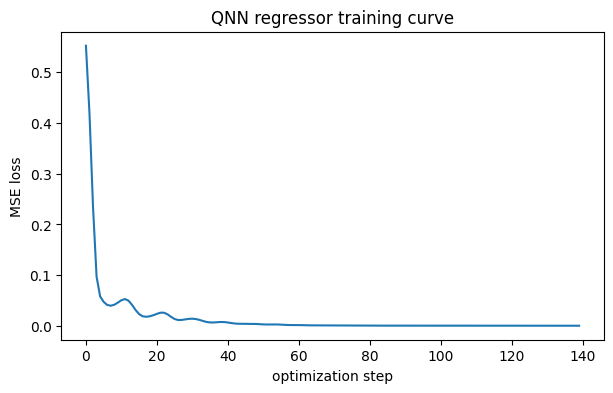

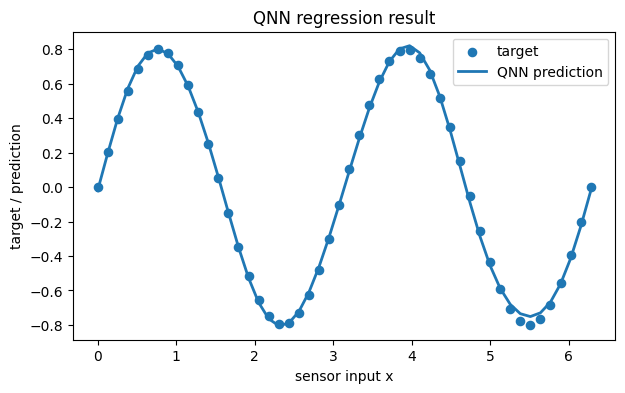

Once again, the regressor with 8 layers outperformed the one with 1 layer.

Adding layers is hurtufll for very simple data but helpfull for more complex data (like the first function).

---
# 3. QNN example 2: binary classification

## 3.1 Practical example: simple quality-control classification

Imagine a factory has two sensor measurements for each product:

- $x_1$: normalized vibration,
- $x_2$: normalized temperature.

The product must be classified as:

- class $-1$: normal,
- class $+1$: needs inspection.

We will use a synthetic nonlinear dataset as a stand-in for this type of two-feature decision problem. The goal is to see the QNN classification pipeline clearly.

The QNN will output:

$$
f(\mathbf{x}; \boldsymbol{\theta}) = \langle Z_0\rangle.
$$

Then we classify with:

$$
\hat{y} =
\begin{cases}
+1, & f(\mathbf{x}; \boldsymbol{\theta}) \ge 0,\\
-1, & f(\mathbf{x}; \boldsymbol{\theta}) < 0.
\end{cases}
$$


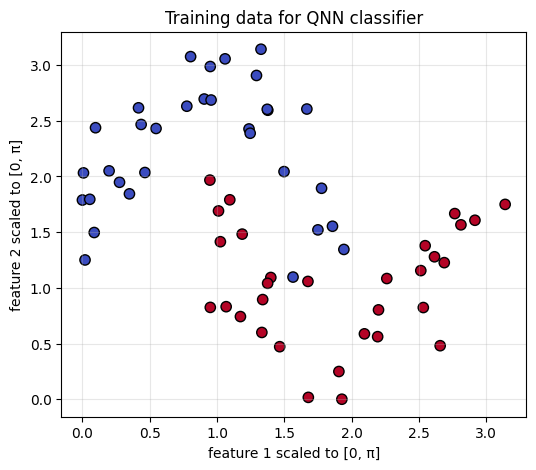

Training samples: 63
Test samples: 27


In [30]:
# Create and scale the binary classification dataset

X_raw, y_raw = make_moons(n_samples=90, noise=0.18, random_state=3)
y_pm = onp.where(y_raw == 0, -1, 1)

# Rotation gates are periodic, so scaling features to [0, π] is convenient.
scaler_qnn = MinMaxScaler(feature_range=(0, onp.pi))
X_scaled = scaler_qnn.fit_transform(X_raw)

X_train_qnn, X_test_qnn, y_train_qnn, y_test_qnn = train_test_split(
    X_scaled,
    y_pm,
    test_size=0.30,
    random_state=12,
    stratify=y_pm
)

X_train_qnn = np.array(X_train_qnn, requires_grad=False)
X_test_qnn = np.array(X_test_qnn, requires_grad=False)
y_train_qnn = np.array(y_train_qnn, requires_grad=False)
y_test_qnn = np.array(y_test_qnn, requires_grad=False)

plt.figure(figsize=(6, 5))
plt.scatter(
    onp.asarray(X_train_qnn)[:, 0],
    onp.asarray(X_train_qnn)[:, 1],
    c=onp.asarray(y_train_qnn),
    cmap="coolwarm",
    edgecolor="k",
    s=55,
)
plt.xlabel("feature 1 scaled to [0, π]")
plt.ylabel("feature 2 scaled to [0, π]")
plt.title("Training data for QNN classifier")
plt.grid(alpha=0.3)
plt.show()

print("Training samples:", len(X_train_qnn))
print("Test samples:", len(X_test_qnn))

Parameter tensor shape: (3, 2, 3)
Number of trainable parameters: 18
Initial output for first training sample: -0.5527880444529161


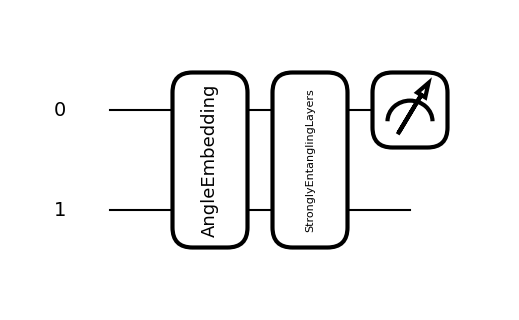

In [49]:
# Define the QNN classifier

n_qubits_qnn = 2
n_layers_qnn = 3

dev_qnn = qml.device("default.qubit", wires=n_qubits_qnn)

@qml.qnode(dev_qnn, interface="autograd", diff_method="backprop")
def qnn_classifier(params, x):
    qml.AngleEmbedding(features=x, wires=range(n_qubits_qnn), rotation="X")
    qml.StronglyEntanglingLayers(weights=params, wires=range(n_qubits_qnn))
    return qml.expval(qml.PauliZ(0))

shape_qnn = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers_qnn,
    n_wires=n_qubits_qnn
)

params_qnn = np.array(
    0.1 * rng.normal(size=shape_qnn),
    requires_grad=True
)

print("Parameter tensor shape:", shape_qnn)
print("Number of trainable parameters:", params_qnn.size)
print("Initial output for first training sample:", qnn_classifier(params_qnn, X_train_qnn[0]))

fig, ax = qml.draw_mpl(qnn_classifier, decimals=2)(params_qnn, X_train_qnn[0])
plt.show()

In [50]:
# Train the QNN classifier

def classifier_loss(params, X, y):
    raw_outputs = np.stack([qnn_classifier(params, x) for x in X])
    return np.mean((raw_outputs - y) ** 2)

def qnn_predict(params, X):
    raw_outputs = onp.array([float(qnn_classifier(params, x)) for x in X])
    return onp.where(raw_outputs >= 0, 1, -1)

def qnn_accuracy(params, X, y):
    preds = qnn_predict(params, X)
    return accuracy_score(onp.asarray(y), preds)

opt = qml.AdamOptimizer(stepsize=0.12)

n_epochs_qnn = 70
batch_size = 18

log_epochs = []
train_losses = []
train_accs = []
test_accs = []

for epoch in range(n_epochs_qnn):
    batch_ids = rng.choice(len(X_train_qnn), size=batch_size, replace=False)
    X_batch = X_train_qnn[batch_ids]
    y_batch = y_train_qnn[batch_ids]

    params_qnn, batch_loss = opt.step_and_cost(
        lambda p: classifier_loss(p, X_batch, y_batch),
        params_qnn
    )

    if epoch % 5 == 0 or epoch == n_epochs_qnn - 1:
        train_loss = float(classifier_loss(params_qnn, X_train_qnn, y_train_qnn))
        train_acc = qnn_accuracy(params_qnn, X_train_qnn, y_train_qnn)
        test_acc = qnn_accuracy(params_qnn, X_test_qnn, y_test_qnn)

        log_epochs.append(epoch)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(
            f"epoch {epoch:3d} | "
            f"loss = {train_loss:.4f} | "
            f"train acc = {train_acc:.3f} | "
            f"test acc = {test_acc:.3f}"
        )

print("\nConfusion matrix on test set:")
print(confusion_matrix(onp.asarray(y_test_qnn), qnn_predict(params_qnn, X_test_qnn)))

epoch   0 | loss = 1.9287 | train acc = 0.286 | test acc = 0.407
epoch   5 | loss = 0.6141 | train acc = 0.841 | test acc = 0.926
epoch  10 | loss = 0.4325 | train acc = 0.889 | test acc = 0.741
epoch  15 | loss = 0.4672 | train acc = 0.857 | test acc = 0.926
epoch  20 | loss = 0.4907 | train acc = 0.841 | test acc = 0.889
epoch  25 | loss = 0.4131 | train acc = 0.905 | test acc = 0.852
epoch  30 | loss = 0.4065 | train acc = 0.857 | test acc = 0.889
epoch  35 | loss = 0.3880 | train acc = 0.857 | test acc = 0.889
epoch  40 | loss = 0.3802 | train acc = 0.873 | test acc = 0.852
epoch  45 | loss = 0.3863 | train acc = 0.841 | test acc = 0.889
epoch  50 | loss = 0.3661 | train acc = 0.873 | test acc = 0.852
epoch  55 | loss = 0.3723 | train acc = 0.857 | test acc = 0.852
epoch  60 | loss = 0.3665 | train acc = 0.857 | test acc = 0.889
epoch  65 | loss = 0.3584 | train acc = 0.857 | test acc = 0.889
epoch  69 | loss = 0.3592 | train acc = 0.873 | test acc = 0.889

Confusion matrix on test

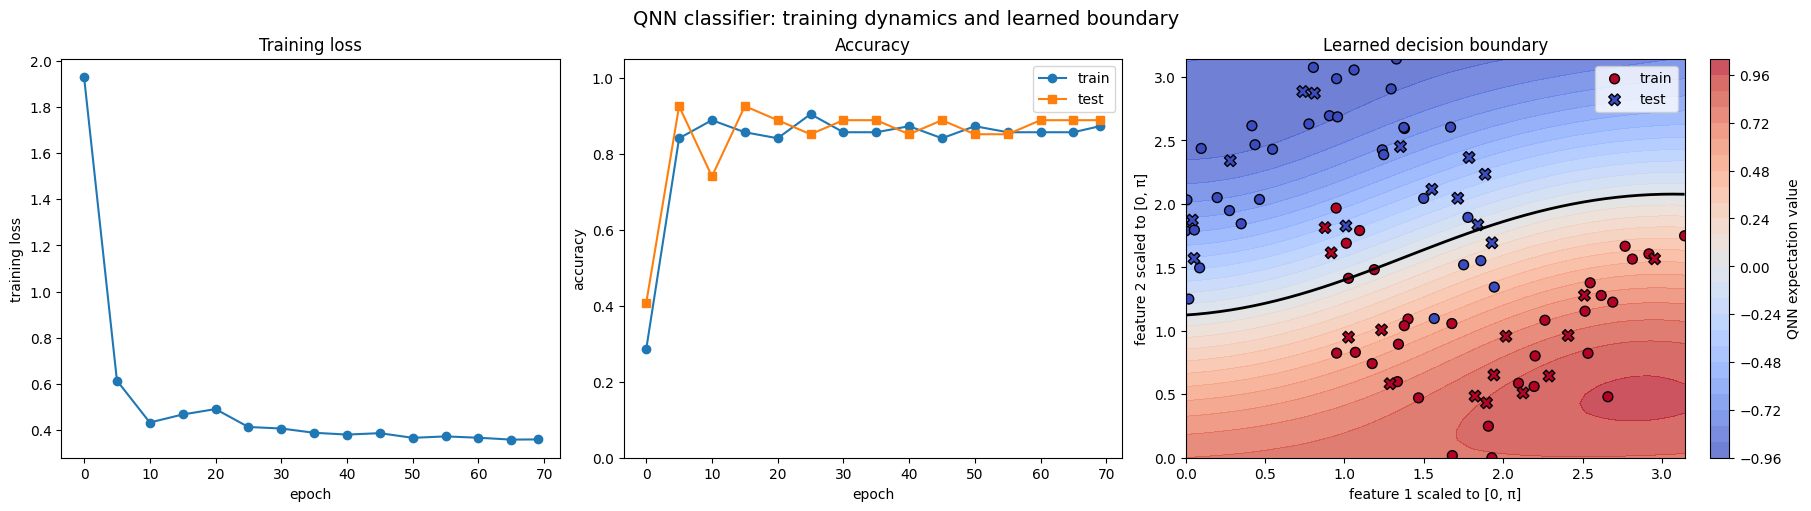

In [51]:
# Visualize training and the learned decision boundary

# Decision boundary in the scaled feature space
grid_steps = 45
xx, yy = onp.meshgrid(
    onp.linspace(0, onp.pi, grid_steps),
    onp.linspace(0, onp.pi, grid_steps)
)
grid_points = onp.c_[xx.ravel(), yy.ravel()]
Z = onp.array([float(qnn_classifier(params_qnn, x)) for x in grid_points])
Z = Z.reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

axes[0].plot(log_epochs, train_losses, marker="o")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss")

axes[1].plot(log_epochs, train_accs, marker="o", label="train")
axes[1].plot(log_epochs, test_accs, marker="s", label="test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Accuracy")
axes[1].legend()

# Panel 3: learned decision boundary
boundary = axes[2].contourf(xx, yy, Z, levels=25, cmap="coolwarm", alpha=0.75)
axes[2].contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)
train_points = axes[2].scatter(
    onp.asarray(X_train_qnn)[:, 0],
    onp.asarray(X_train_qnn)[:, 1],
    c=onp.asarray(y_train_qnn),
    cmap="coolwarm",
    edgecolor="k",
    s=50,
    label="train",
)
axes[2].scatter(
    onp.asarray(X_test_qnn)[:, 0],
    onp.asarray(X_test_qnn)[:, 1],
    c=onp.asarray(y_test_qnn),
    cmap="coolwarm",
    edgecolor="k",
    marker="X",
    s=70,
    label="test",
)
axes[2].set_xlabel("feature 1 scaled to [0, π]")
axes[2].set_ylabel("feature 2 scaled to [0, π]")
axes[2].set_title("Learned decision boundary")
axes[2].legend(loc="upper right")
fig.colorbar(boundary, ax=axes[2], label="QNN expectation value")

fig.suptitle("QNN classifier: training dynamics and learned boundary", fontsize=14)
plt.show()


## 3.6 Important observations about QNN classifiers

### The QNN is not trained like a classical SVM

The QNN directly trains circuit parameters $\boldsymbol{\theta}$. It does not construct a margin-maximizing hyperplane.

### The output is probabilistic in hardware

In simulation, `default.qubit` can return exact expectation values. On real quantum hardware, the same expectation value would be estimated from repeated measurements, so the output has sampling noise.

### Circuit architecture matters

The encoding, entangling pattern, number of layers, and measured observable define the model class. A poor ansatz can underfit. A very deep ansatz can become hard to train.

### Scaling matters

Inputs were scaled to $[0,\pi]$ because rotation gates interpret inputs as angles. If raw features have very different ranges, the QNN can behave erratically.

### In-class exercise 3.A — QNN classifier experiments

Use the QNN classifier above.

1. Change `n_layers_qnn` from 3 to 1.
2. Retrain the model and compare train/test accuracy.
3. Change `rotation="Y"` to `rotation="X"` in `AngleEmbedding`.
4. Retrain and compare the decision boundary.
5. Add a trainable scalar bias $b$ after the circuit output:

$$
f_b(\mathbf{x}) = \langle Z_0\rangle + b.
$$

6. Does the bias improve classification? Why might it help?

**Note:** The bias is classical. It is common in hybrid models to combine quantum circuit outputs with small classical post-processing.

 ### With n_layers_qnn equal to 1

 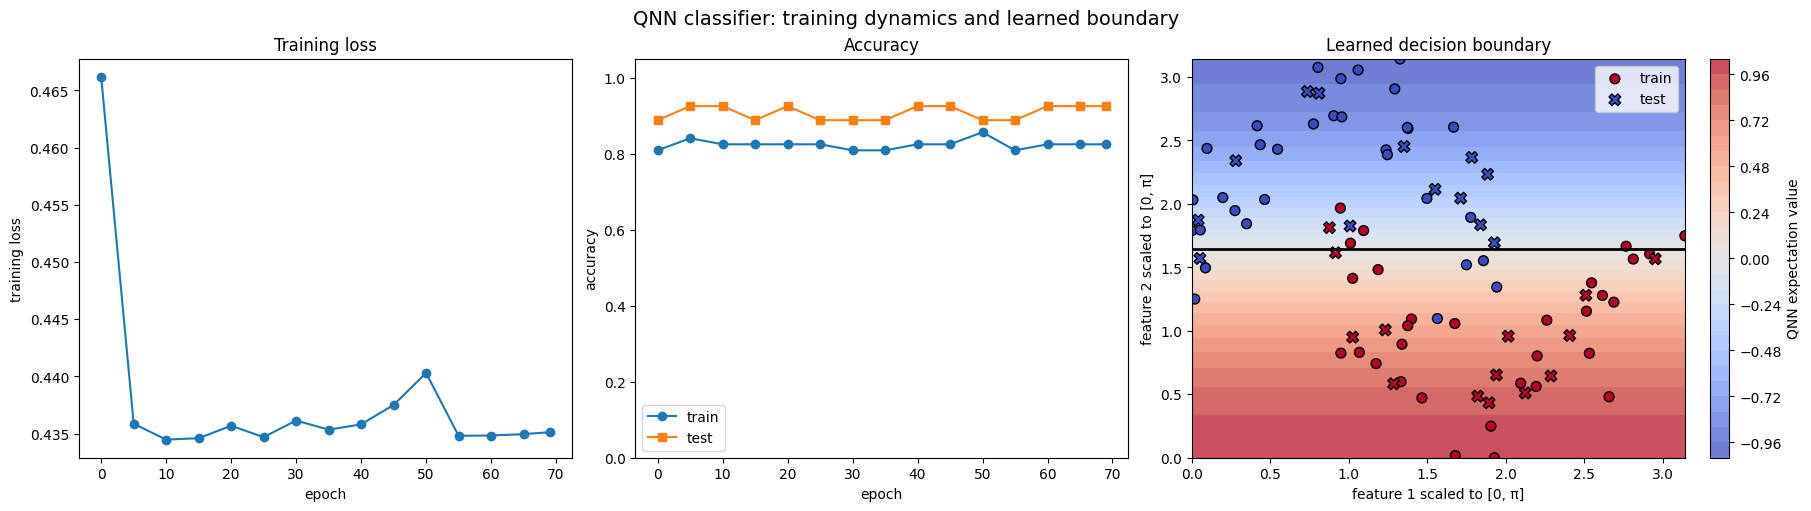

 Training and test accuracy almost dont change for the new qnn.


 ### With n_layers_qnn equal to 3 and angle embedding = X
 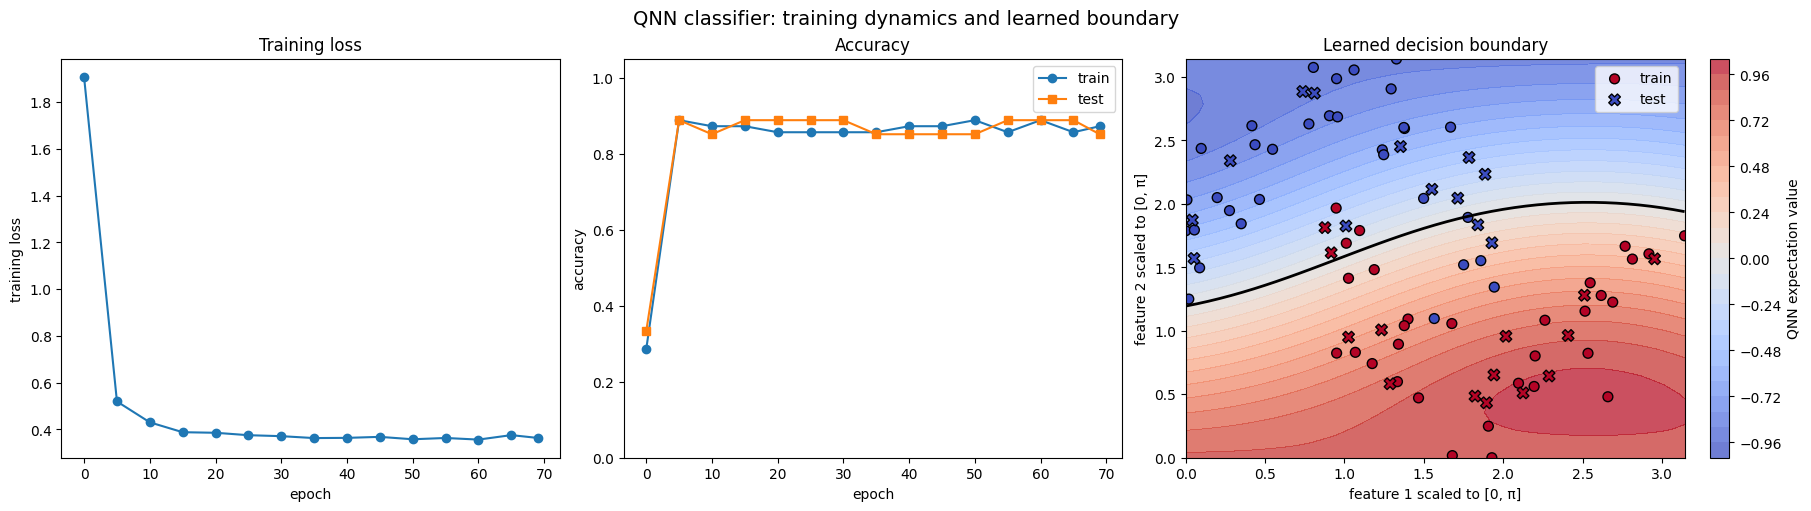

---
# 4. Quantum Support Vector Machines (QSVMs)

## 4.1 Classical SVM recap

A support vector machine tries to find a decision boundary with a large margin between two classes. With a kernel function $k$, the SVM does not need explicit transformed features. It only needs similarities:

$$
K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j).
$$

A classical nonlinear kernel, such as the radial basis function (RBF) kernel, maps data implicitly into a richer feature space.

---

## 4.2 Quantum kernel idea

A quantum feature map prepares a quantum state:

$$
\mathbf{x} \mapsto |\phi(\mathbf{x})\rangle.
$$

The quantum kernel is:

$$
k_Q(\mathbf{x}, \mathbf{x}')
=
|\langle \phi(\mathbf{x}) | \phi(\mathbf{x}') \rangle|^2.
$$

So a QSVM in the NISQ kernel-estimation style is:

$$
\boxed{
\text{quantum circuit computes } K
\quad \rightarrow \quad
\text{classical SVM trains with } K
}
$$

This is different from the QNN approach:

- QNN: train circuit parameters.
- QSVM: usually choose a feature map, compute a kernel matrix, and train a classical SVM.

---

## 4.3 What does “QSVM” mean?

There are at least two meanings in the literature.

1. **Fault-tolerant / algorithmic QSVM:**  
   Quantum linear-algebra subroutines are used to speed up parts of SVM training under strong assumptions.

2. **NISQ quantum-kernel SVM:**  
   A near-term quantum circuit estimates the kernel entries $K_{ij}$, and a classical SVM solves the optimization.

This notebook focuses on the second version because it is directly implementable with PennyLane and small simulators.

Kernel k(x_a, x_a): 1.0
Kernel k(x_a, x_b): 0.9611239360803382
Kernel k(x_b, x_a): 0.9611239360803382

Feature map circuit:


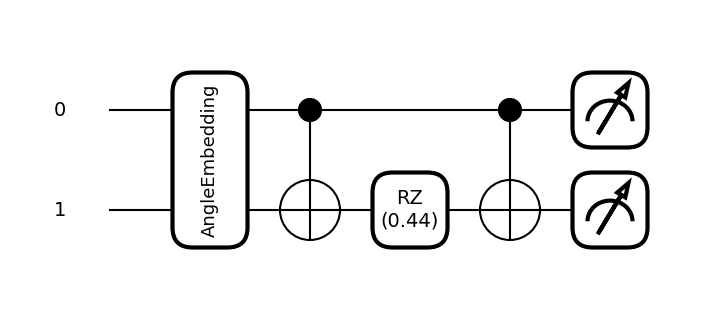

Overlap circuit used to estimate k(x_a, x_b):


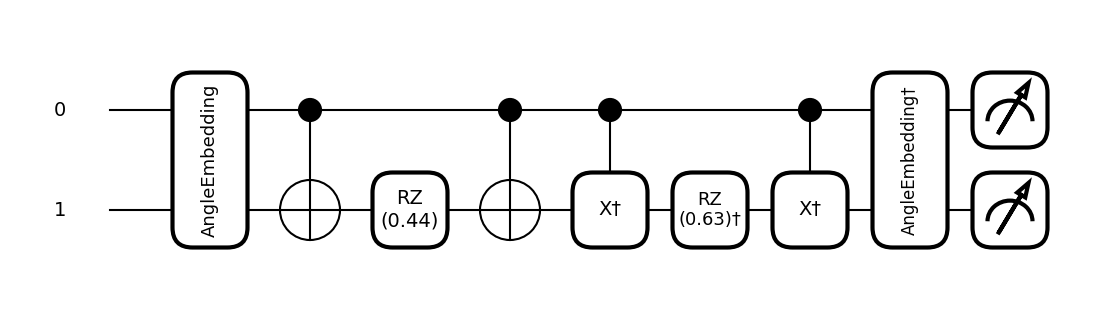

In [ ]:
# Define a quantum feature map and an overlap kernel

n_qubits_kernel = 2
dev_kernel = qml.device("default.qubit", wires=n_qubits_kernel)

def qsvm_feature_map(x):
    # A simple 2-qubit feature map.
    #
    # The first part uses angle encoding.
    # The second part adds an entangling phase depending on x[0] * x[1].
    qml.AngleEmbedding(features=x, wires=range(n_qubits_kernel), rotation="Y")

    # A simple ZZ-like entangling feature
    qml.CNOT(wires=[0, 1])
    qml.RZ(x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])

@qml.qnode(dev_kernel)
def feature_map_state(x):
    qsvm_feature_map(x)
    return qml.state()

@qml.qnode(dev_kernel)
def qsvm_overlap_circuit(x1, x2):
    qsvm_feature_map(x1)
    qml.adjoint(qsvm_feature_map)(x2)
    return qml.probs(wires=range(n_qubits_kernel))

def quantum_kernel(x1, x2):
    # Probability of measuring |00> after U(x1) followed by U(x2)†
    return float(qsvm_overlap_circuit(x1, x2)[0])

x_a = np.array([0.4, 1.1], requires_grad=False)
x_b = np.array([0.7, 0.9], requires_grad=False)

print("Kernel k(x_a, x_a):", quantum_kernel(x_a, x_a))
print("Kernel k(x_a, x_b):", quantum_kernel(x_a, x_b))
print("Kernel k(x_b, x_a):", quantum_kernel(x_b, x_a))

print("\nFeature map circuit:")
fig, ax = qml.draw_mpl(feature_map_state, decimals=2)(x_a)
plt.show()

print("Overlap circuit used to estimate k(x_a, x_b):")
fig, ax = qml.draw_mpl(qsvm_overlap_circuit, decimals=2)(x_a, x_b)
plt.show()

## 4.5 Why the overlap circuit works

Let the feature-map unitary be $U_\phi(\mathbf{x})$, so that:

$$
|\phi(\mathbf{x})\rangle = U_\phi(\mathbf{x})|0\rangle.
$$

The overlap circuit applies:

$$
U_\phi^\dagger(\mathbf{x}')U_\phi(\mathbf{x})|0\rangle.
$$

The probability of returning to $|00\cdots 0\rangle$ is:

$$
P(00\cdots 0)
=
|\langle 0|U_\phi^\dagger(\mathbf{x}')U_\phi(\mathbf{x})|0\rangle|^2
=
|\langle \phi(\mathbf{x}')|\phi(\mathbf{x})\rangle|^2.
$$

This is exactly the quantum kernel value.

Quantum kernel matrix:
[[1.     0.9949 0.5897 0.4951 0.0402 0.0269]
 [0.9949 1.     0.6272 0.5238 0.0577 0.0412]
 [0.5897 0.6272 1.     0.9822 0.2022 0.2441]
 [0.4951 0.5238 0.9822 1.     0.1871 0.2526]
 [0.0402 0.0577 0.2022 0.1871 1.     0.9591]
 [0.0269 0.0412 0.2441 0.2526 0.9591 1.    ]]

Symmetric? True
Diagonal approximately 1? True
Eigenvalues: [8.130000e-04 1.105200e-02 4.039200e-02 8.196040e-01 1.907949e+00
 3.220190e+00]


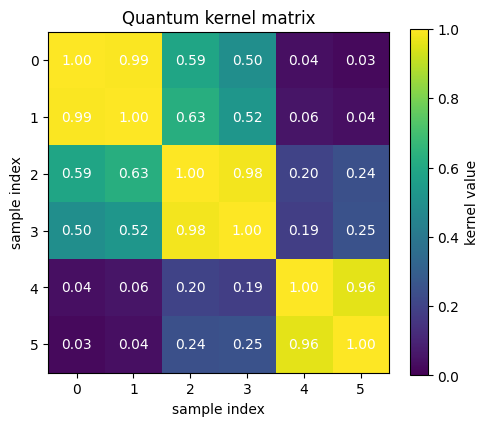

In [ ]:
# Compute and inspect a small quantum kernel matrix

X_kernel_demo = np.array(
    [
        [0.2, 0.3],
        [0.3, 0.4],
        [1.2, 1.0],
        [1.3, 1.1],
        [2.5, 2.4],
        [2.6, 2.5],
    ],
    requires_grad=False
)

K_demo = np.array(
    qml.kernels.kernel_matrix(X_kernel_demo, X_kernel_demo, quantum_kernel)
)

print("Quantum kernel matrix:")
print(onp.round(onp.asarray(K_demo), 4))

print("\nSymmetric?", onp.allclose(onp.asarray(K_demo), onp.asarray(K_demo).T))
print("Diagonal approximately 1?", onp.allclose(onp.diag(onp.asarray(K_demo)), 1.0))

eigvals = onp.linalg.eigvalsh(onp.asarray(K_demo))
print("Eigenvalues:", onp.round(eigvals, 6))

plt.figure(figsize=(5.5, 4.5))
plt.imshow(onp.asarray(K_demo), vmin=0, vmax=1, cmap="viridis")
plt.colorbar(label="kernel value")
plt.title("Quantum kernel matrix")
plt.xlabel("sample index")
plt.ylabel("sample index")
for i in range(len(X_kernel_demo)):
    for j in range(len(X_kernel_demo)):
        plt.text(j, i, f"{K_demo[i, j]:.2f}", ha="center", va="center", color="white")
plt.show()

### In-class exercise 4.A — Quantum-kernel properties

Using `X_kernel_demo`, `quantum_kernel`, and `K_demo`:

1. Change one point so that two samples are identical. What happens to the corresponding kernel value?
2. Remove the entangling block from `qsvm_feature_map`. Recompute the kernel matrix.
3. Compare the two kernel matrices visually.
4. Compute the eigenvalues of both matrices.
5. Why should a valid kernel matrix be positive semidefinite?

**Note:** A more complicated feature map does not automatically make a better kernel. It must create useful similarities for the task.

---
# 5. QSVM example: nonlinear binary classification

## 5.1 Practical example: anomaly classification

Suppose each machine observation has two features:

- normalized vibration,
- normalized heat.

The label indicates:

- class $-1$: normal operation,
- class $+1$: possible anomaly.

The boundary may be nonlinear. We will train:

1. a classical linear SVM,
2. a classical RBF SVM,
3. a quantum-kernel SVM.

The quantum model is still an SVM. The difference is the source of the kernel matrix.

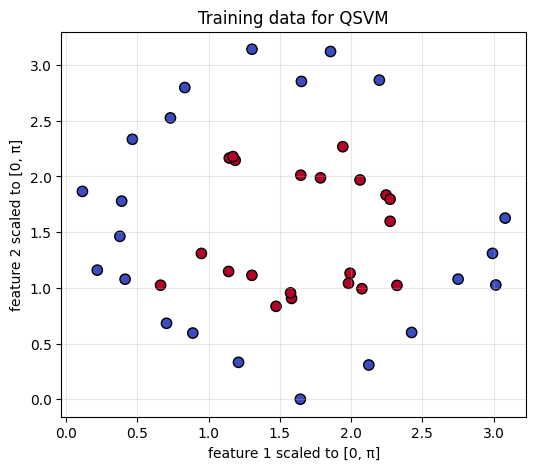

Training samples: 44
Test samples: 20
Kernel entries needed for training: 1936


In [ ]:
# Create data for the QSVM

X_raw_svm, y_raw_svm = make_circles(
    n_samples=64,
    noise=0.10,
    factor=0.45,
    random_state=7
)

y_svm_pm = onp.where(y_raw_svm == 0, -1, 1)

scaler_svm = MinMaxScaler(feature_range=(0, onp.pi))
X_svm_scaled = scaler_svm.fit_transform(X_raw_svm)

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm_scaled,
    y_svm_pm,
    test_size=0.30,
    random_state=4,
    stratify=y_svm_pm
)

X_train_svm = np.array(X_train_svm, requires_grad=False)
X_test_svm = np.array(X_test_svm, requires_grad=False)

plt.figure(figsize=(6, 5))
plt.scatter(
    onp.asarray(X_train_svm)[:, 0],
    onp.asarray(X_train_svm)[:, 1],
    c=y_train_svm,
    cmap="coolwarm",
    edgecolor="k",
    s=55,
)
plt.xlabel("feature 1 scaled to [0, π]")
plt.ylabel("feature 2 scaled to [0, π]")
plt.title("Training data for QSVM")
plt.grid(alpha=0.3)
plt.show()

print("Training samples:", len(X_train_svm))
print("Test samples:", len(X_test_svm))
print("Kernel entries needed for training:", len(X_train_svm) ** 2)

In [ ]:
# Train a QSVM with a precomputed quantum kernel

# Compute quantum kernel matrices.
# K_train has shape (n_train, n_train).
# K_test has shape (n_test, n_train), because sklearn compares
# each test point against the training points.
K_train = onp.array(
    qml.kernels.kernel_matrix(X_train_svm, X_train_svm, quantum_kernel)
)

K_test = onp.array(
    qml.kernels.kernel_matrix(X_test_svm, X_train_svm, quantum_kernel)
)

qsvm = SVC(kernel="precomputed", C=1.0)
qsvm.fit(K_train, y_train_svm)

qsvm_train_pred = qsvm.predict(K_train)
qsvm_test_pred = qsvm.predict(K_test)

print("QSVM train accuracy:", accuracy_score(y_train_svm, qsvm_train_pred))
print("QSVM test accuracy: ", accuracy_score(y_test_svm, qsvm_test_pred))
print("Number of support vectors:", qsvm.n_support_)

# Classical baselines on the same scaled data
linear_svm = SVC(kernel="linear", C=1.0)
linear_svm.fit(onp.asarray(X_train_svm), y_train_svm)

rbf_svm = SVC(kernel="rbf", C=1.0, gamma="scale")
rbf_svm.fit(onp.asarray(X_train_svm), y_train_svm)

print("\nClassical linear SVM test accuracy:",
      accuracy_score(y_test_svm, linear_svm.predict(onp.asarray(X_test_svm))))

print("Classical RBF SVM test accuracy:",
      accuracy_score(y_test_svm, rbf_svm.predict(onp.asarray(X_test_svm))))

QSVM train accuracy: 0.9545454545454546
QSVM test accuracy:  0.95
Number of support vectors: [14 14]

Classical linear SVM test accuracy: 0.45
Classical RBF SVM test accuracy: 1.0


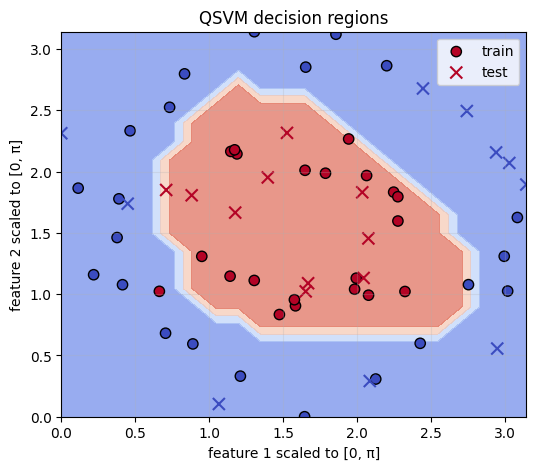

In [ ]:
# Visualize the QSVM decision boundary

grid_steps = 22
xx, yy = onp.meshgrid(
    onp.linspace(0, onp.pi, grid_steps),
    onp.linspace(0, onp.pi, grid_steps)
)

grid_points = np.array(onp.c_[xx.ravel(), yy.ravel()], requires_grad=False)

K_grid = onp.array(
    qml.kernels.kernel_matrix(grid_points, X_train_svm, quantum_kernel)
)

grid_pred = qsvm.predict(K_grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, grid_pred, levels=2, cmap="coolwarm", alpha=0.65)
plt.scatter(
    onp.asarray(X_train_svm)[:, 0],
    onp.asarray(X_train_svm)[:, 1],
    c=y_train_svm,
    cmap="coolwarm",
    edgecolor="k",
    s=55,
    label="train",
)
plt.scatter(
    onp.asarray(X_test_svm)[:, 0],
    onp.asarray(X_test_svm)[:, 1],
    c=y_test_svm,
    cmap="coolwarm",
    marker="x",
    s=75,
    label="test",
)
plt.xlabel("feature 1 scaled to [0, π]")
plt.ylabel("feature 2 scaled to [0, π]")
plt.title("QSVM decision regions")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 5.5 Interpreting the QSVM result

The QSVM did not train quantum circuit parameters. It used the quantum feature map to define a kernel matrix:

$$
K_{ij} = k_Q(\mathbf{x}_i, \mathbf{x}_j).
$$

Then `SVC(kernel="precomputed")` solved the usual SVM optimization problem.

This leads to a useful separation:

- **Quantum part:** estimate pairwise similarities.
- **Classical part:** solve the margin-maximization problem.

The cost is that kernel methods scale at least quadratically in the number of training samples because many pairwise kernel values are required.

### Exercise 5.A — QSVM feature-map comparison

Modify the `qsvm_feature_map` function.

1. Remove the entangling block and use only `AngleEmbedding`.
2. Recompute `K_train` and `K_test`.
3. Retrain the QSVM.
4. Compare test accuracy with the entangling feature map.
5. Add a second repetition of the feature map:

$$
U_\phi(\mathbf{x}) \rightarrow U_\phi(\mathbf{x})U_\phi(\mathbf{x}).
$$

6. Does repetition help or hurt?

**Discussion question:** In a QSVM, which plays a role similar to model architecture: the SVM hyperparameters, the quantum feature map, or both?

---
# 6. QNNs vs QSVMs

| Aspect | QNN | QSVM / quantum-kernel SVM |
|---|---|---|
| Main quantum object | trainable parameterized circuit | fixed feature-map circuit |
| What is optimized? | circuit parameters $\boldsymbol{\theta}$ | classical SVM dual variables |
| Quantum evaluations | during every training step | mostly during kernel-matrix construction |
| Output | expectation value(s) | kernel entries |
| Typical prediction rule | sign of measured expectation | SVM decision function |
| Main design choice | ansatz, depth, measurements, encoding | feature map, kernel, SVM $C$ |
| Strength | flexible end-to-end model | stable convex classical optimization after kernel computation |
| Weakness | training can be hard | kernel matrix scales poorly with dataset size |

---

## When might you choose each one?

Choose a **QNN** when:

- you want a trainable quantum representation,
- you want end-to-end optimization,
- you can experiment with ansätze and measurements,
- the dataset is small enough for repeated circuit evaluation.

Choose a **QSVM** when:

- you want to study quantum feature maps,
- you want a convex classical optimization stage,
- you can afford pairwise kernel evaluations,
- you want to compare quantum kernels against classical kernels.

In research practice, both should be compared against strong classical baselines. A quantum model is only useful if it offers better accuracy, better scaling, better robustness, or a domain-specific advantage.

---
# 7. Homework

Submit a Jupyter/Colab notebook with executed cells and written explanations. Code without interpretation is not sufficient.

---

## Homework 1 — QNN architecture study

Use the QNN classifier from Section 3.

1. Train models with 1, 2, 3, and 4 strongly entangling layers.
2. Record train accuracy, test accuracy, and number of trainable parameters.
3. Plot accuracy versus number of layers.
4. Draw the circuit for the best-performing depth.
5. Explain whether the deepest model was the best model.

---

## Homework 2 — QNN regression with data re-uploading

Use the QNN regressor from Section 2.

Change the target function to:

$$
y(x) = 0.5\sin(x) + 0.3\sin(3x).
$$

1. Train with 1, 2, 4, and 8 re-uploading layers.
2. Plot the learned function for each case.
3. Report the final MSE for each case.
4. Explain why data re-uploading can increase expressivity.

---

## Homework 3 — Quantum-kernel analysis

For the 2-qubit `AngleEmbedding` feature map with $R_Y$ rotations and **no entangling gates**, derive the analytical kernel:

$$
k(\mathbf{x}, \mathbf{x}')
=
|\langle \phi(\mathbf{x})|\phi(\mathbf{x}')\rangle|^2.
$$

Tasks:

1. Derive the one-qubit overlap for $R_Y(x)|0\rangle$.
2. Extend the result to two qubits.
3. Verify your formula numerically with PennyLane.
4. Compare the analytical kernel matrix with `qml.kernels.kernel_matrix`.

---

## Homework 4 — QSVM feature-map benchmark

Using the QSVM pipeline from Section 5:

1. Compare three feature maps:
   - `AngleEmbedding` only,
   - `AngleEmbedding` plus the entangling phase used in this notebook,
   - two repetitions of the entangling feature map.
2. For each feature map, compute train/test accuracy.
3. Plot the three kernel matrices.
4. Compare the QSVM results against linear and RBF SVM baselines.
5. Write a short conclusion: which feature map worked best and why do you think it helped?

---
# 8. References and further reading

## PennyLane documentation

- PennyLane `AngleEmbedding`: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html
- PennyLane `StronglyEntanglingLayers`: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html
- PennyLane `draw_mpl`: https://docs.pennylane.ai/en/stable/code/api/pennylane.draw_mpl.html
- PennyLane `qml.kernels.kernel_matrix`: https://docs.pennylane.ai/en/stable/code/api/pennylane.kernels.kernel_matrix.html

## Papers

- Schuld, M., Bocharov, A., Svore, K., & Wiebe, N. (2018). *Circuit-centric quantum classifiers*. arXiv:1804.00633.
- Havlíček, V. et al. (2018). *Supervised learning with quantum-enhanced feature spaces*. arXiv:1804.11326.
- Rebentrost, P., Mohseni, M., & Lloyd, S. (2013). *Quantum support vector machine for big data classification*. arXiv:1307.0471.